In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import jax.nn as jnn
from jax.random import PRNGKey
import optax
import gymnax
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from dataclasses import dataclass

@dataclass
class SharedConfig:
    seed: int = 42
    env_name: str = "Pendulum-v1"
    gamma: float = 0.99
    horizon: int = 200          # will be overridden by env_params.max_steps_in_episode if different
    num_actions: int = 3
    action_max: float = 2.0     # Pendulum torque bound in Gym/Gymnax

cfg = SharedConfig()


In [3]:
key = PRNGKey(cfg.seed)
key, key_reset, key_policy, key_step = jr.split(key, 4)

# Create the Pendulum-v1 environment
env_name = cfg.env_name
env, env_params = gymnax.make(env_name)

# Inspect default environment settings
print(env_params)
ts = jnp.arange(0, env_params.dt * env_params.max_steps_in_episode, env_params.dt)

obs, state = env.reset(key_reset, env_params)
obs, state

EnvParams(max_steps_in_episode=200, max_speed=8.0, max_torque=2.0, dt=0.05, g=10.0, m=1.0, l=1.0)


(Array([0.13987947, 0.9901685 , 0.5757351 ], dtype=float32),
 EnvState(time=Array(0, dtype=int32, weak_type=True), theta=Array(1.4304566, dtype=float32), theta_dot=Array(0.5757351, dtype=float32), last_u=Array(0., dtype=float32, weak_type=True)))

In [4]:
action = env.action_space(env_params).sample(key_policy)
action_scalar = env.action_space() 
n_obs, n_state, reward, done, _ = env.step(key_step, state, action, env_params)
n_obs, n_state, reward, done

(Array([0.06934873, 0.99759245, 1.4187058 ], dtype=float32),
 EnvState(time=Array(1, dtype=int32, weak_type=True), theta=Array(1.5013919, dtype=float32), theta_dot=Array(1.4187058, dtype=float32), last_u=Array(0.6689625, dtype=float32)),
 Array(-2.0798001, dtype=float32),
 Array(False, dtype=bool, weak_type=True))

In [5]:
obs, state = env.reset(key_reset, env_params)
action = env.action_space().sample(key_policy)
action_list = jnp.linspace(-cfg.action_max, cfg.action_max, cfg.num_actions).astype(jnp.float32) 
num_actions = cfg.num_actions
n_obs, n_state, reward, done, _ = env.step(key_step, state, action)

env_params

EnvParams(max_steps_in_episode=200, max_speed=8.0, max_torque=2.0, dt=0.05, g=10.0, m=1.0, l=1.0)

In [6]:
def initialize_mlp(layer_sizes, key:PRNGKey, scale:float=1e-2):
    """
    Inputs:
        layer_sizes (tuple) Tuple of shapes of the neural network layers. Includes the input shape, hidden layer shape, and output layer shape.
        key (PRNGKey) 
        scale (float) standard deviation of initial weights and biases

    Return: 
        params (List) Tuple of weights and biases - [ (weights_1, biases_1), ..., (weights_n, biases_n) ]
    """
    keys = jr.split(key, 2*len(layer_sizes))
    params = []

    for i in range(len(layer_sizes[:-1])):
        input, output = layer_sizes[i], layer_sizes[i+1]
        W = jr.normal(keys[i], (input, output))*scale
        b = jr.normal(keys[i+1], (output,))*scale
        params.append((W, b))

    return params

def policy(params, x):
    """ Standard MLP that predicts either -1, 0, 1.
    
    Inputs:
        params (PyTree) Parameters of the policy network, represented as PyTree. 
        x (D,) input state, where D is the dimensionality of the state observation.
        """

    for (W, b) in params[:-1]:
        x = jnp.dot(x, W) + b
        x = jax.nn.relu(x)

    # Output layer mean
    W, b = params[-1]
    return jax.nn.softmax(jnp.dot(x, W) + b)

In [7]:
def get_action(params, x, key:PRNGKey):
    """  
    Sample an action using the action probabilities predicted by the MLP

    Input:
        params (PyTree) Parameters of the policy network, represented as PyTree. 
        x (D,) input state, where D is the dimensionality of the state observation.
        key (PRNGKey)
     
    Return:
        action (M,) of floats: actions generated according to params, where M is the dimensionality of actions we carry out. 
        action_idx (M,) of int: indices of actions generated according to params.
    """
    action_probabilities = policy(params, x)
    action_indices = jnp.arange(num_actions)
    sampled_action = jr.choice(key, action_indices, p=action_probabilities)
    return jnp.array([action_list[sampled_action]], dtype=jnp.float32), sampled_action

def get_log_prob(params, x, action_idx):
    """
    Return the log probability of the action executed by the MLP.

    Input:
        params (PyTree) Parameters of the policy network, represented as PyTree. 
        x (D,) input state, where D is the dimensionality of the state observation.
        action_idx (M,) of int: indices of actions generated according to params.
     
    Return:
        log probability
    """
    action_probs = policy(params, x)
    p = action_probs[action_idx]
    return jnp.log(p)

@jax.jit
def update_delta(delta, grad_theta):
    """ 
    Update the parameter update delta with the gradient of the policy.

    Input:
        delta (PyTree) current loss term
        grad_theta (PyTree) gradient update of the network parameters.
    
    Return:
        updated_delta (PyTree) 
    """
    updated_delta = jax.tree.map(lambda x,y: x+y, delta, grad_theta)
    return updated_delta, None

In [8]:
key, subkey = jr.split(key)
layer_sizes = (env.obs_shape[0], 64, num_actions)
params = initialize_mlp(layer_sizes,key=subkey)
# test runs
key, subkey = jr.split(key)
test_action, test_action_idx = get_action(params, obs, subkey)
test_log_prob = get_log_prob(params, obs, test_action_idx)


In [9]:
def rollout(params, env_params, rng_input:PRNGKey, steps_in_episode:int):
    """Rollout a jitted gymnax episode with lax.scan."""
    # Reset the environment
    rng_reset, rng_episode = jr.split(rng_input)
    obs, state = env.reset(rng_reset, env_params)


    def policy_step(state_input, tmp):
        """lax.scan compatible step transition in jax env."""
        obs, state, rng = state_input
        rng, rng_action, rng_step = jr.split(rng, 3)
        action, action_idx = get_action(params, obs, rng_action)
        next_obs, next_state, reward, done, _ = env.step(
          rng_step, state, action, env_params
        )
        carry = [next_obs, next_state, rng]
        return carry, [obs, state, action, action_idx, reward, next_obs, done]

    # Scan over episode step loop
    _, scan_out = jax.lax.scan(
      policy_step,
      [obs, state, rng_episode],
      (),
      length=steps_in_episode, 
    )
    return scan_out

# Jit-Compiled Episode Rollout
jit_rollout = jax.jit(rollout, static_argnums=3)

In [10]:
def visualize_trajectory(params, key):
    obs, state, action, action_idx, reward, next_obs, done = rollout(params, env_params, rng_input=key, steps_in_episode = int(env_params.max_steps_in_episode))

    fig, ax = plt.subplots(5,1,figsize=(8,8))
    # first three plots for the system states
    ax[0].set_title('System states over time')

    for d in range(env.obs_shape[0]):
        ax[d].plot(ts, obs[:,d], color='C0', label=f'State {d}')
    ax[0].set_title(r'$\cos(\theta)$')
    ax[1].set_title(r'$\sin(\theta)$')
    ax[2].set_title(r'$\dot{\theta}$')
    
    ax[3].plot(ts, action, color='C1', label=f'Actions')
    # ax[3].set_ylim((env.action_space().low, env.action_space().high))
    ax[3].set_title('u(t)')
    ax[4].plot(ts, reward, color='C2', label='Rewards')
    ax[4].set_title('r(t)')

    plt.tight_layout()
    plt.show()

Caption 1: Single rollout using the policy network without training


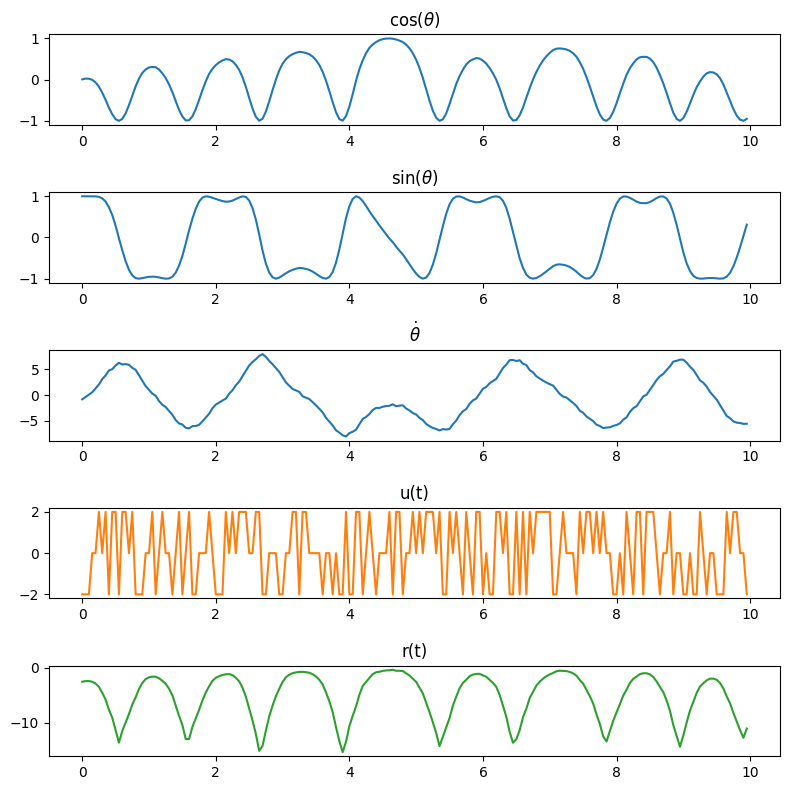

In [11]:
key, subkey = jr.split(key)
print('Caption 1: Single rollout using the policy network without training')
visualize_trajectory(params,key = subkey)

In [12]:
def loss_REINFORCE(params, obs, action_idx, reward, baseline, gamma:float=0.99):
    """
    Compute the error term delta using the REINFORCE algorithm

    Inputs:
        params (PyTree) Current parameters of the network
        obs (Array) Batch of observations
        action_idx (Array) Batch of action indices
        reward (Array) Batch of rewards
        baseline (Array) Baseline over time points - not required for current question 8.3.

    Return:
        delta (PyTree) Error terms of the parameters
        Gt (Array) Batched discounted rewards over time
    """

    def trajectory_gradients(reward, obs, action_idx, baseline, delta):
        G_init = 0

        def step(carry, variables):
            G, delta = carry
            r, obs, action_idx, baseline = variables
            # r, action_idx, baseline = jnp.squeeze(r), jnp.squeeze(action_idx), jnp.squeeze(baseline)

            #Calculate discounted rewards and advantage
            G = gamma*G + r
            A_hat = G - baseline

            #Compute the gradient of the policy parameters
            def loss_function(params):
                logprob = get_log_prob(params, obs, action_idx).squeeze()
                return -logprob

            #Update error terms based on gradients
            grad_delta = jax.grad(loss_function)(params)
            grad_delta = jax.tree.map(lambda gd: gd*A_hat, grad_delta)
            delta, _ = update_delta(delta, grad_delta)

            carry = G, delta
            return carry, G

        #Iterate backwards in time
        variables = (reward[::-1],
                     obs[::-1],
                     action_idx[::-1],
                     baseline[::-1])

        (_, delta), Gt = jax.lax.scan(step, (G_init,delta), variables)
        return delta, Gt

    # create a parallizable function and initialize the error terms delta.
    parallel_trajectory_gradients = jax.vmap(trajectory_gradients, in_axes=(0,0,0,None,None))
    delta = jax.tree.map(lambda t: jnp.zeros(t.shape), params)

    # compute the delta gradients in parallel and sum them up.
    delta = jax.tree.map(lambda t: jnp.zeros(t.shape), params)
    deltas, Gs = parallel_trajectory_gradients(reward, obs, action_idx, baseline, delta)    
    delta, _ = jax.lax.scan(update_delta, delta, deltas)

    return delta, jnp.array(Gs)

loss_REINFORCE = jax.jit(loss_REINFORCE)


In [13]:
# set training parameters
num_iters = 10_000
steps_in_episode = int(env_params.max_steps_in_episode)
lr = 0.005
gamma = cfg.gamma
n_batches = 50

optim = optax.adam(learning_rate=lr)
state = optim.init(params)

In [14]:
# Mini-batch random keys to scan over.
key, subkey = jr.split(key)
params = initialize_mlp(layer_sizes, key=subkey)
iter_keys = jr.split(subkey, num_iters)


# Optimisation step.
def step(carry, key):
    params, opt_state, env_params = carry
    
    # forward pass
    keys = jr.split(key, n_batches)
    parallel_rollout = jax.vmap(rollout, in_axes=(None,None,0,None))
    obs, _, action, action_idx, reward, next_obs, done = parallel_rollout(params, 
                                                         env_params, 
                                                         keys,
                                                         steps_in_episode)
    empty_baseline = jnp.zeros((reward.shape[-1])) 

    # compute gradients and update model
    delta, _ = loss_REINFORCE(params, obs, action_idx, reward, empty_baseline, gamma)
    updates, opt_state = optim.update(delta, opt_state, params)
    new_params = optax.apply_updates(params, updates)

    carry = new_params, opt_state, env_params
    return carry, jnp.mean(jnp.sum(reward,axis=-1))

# Optimisation loop.
(params, _, _), history = jax.lax.scan(step, (params, state, env_params), (iter_keys))

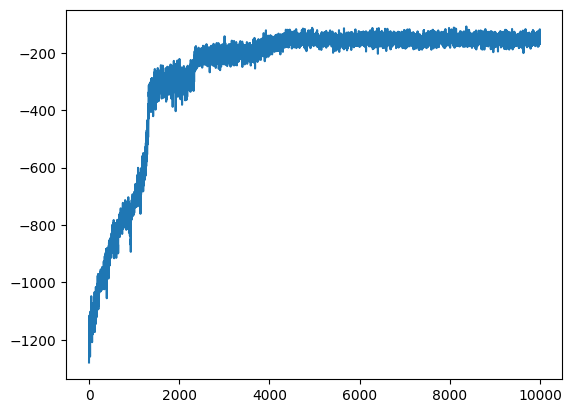

In [15]:
plt.plot(history, label='loss')
plt.show()